# Cross-Market Volatility Risk Premium: Nifty vs SPX (2010–2024)

End-to-end walkthrough: data pipeline → implied vol construction → realized vol / jump decomposition → Mincer-Zarnowitz regressions → VRP decomposition → delta-hedged short-straddle backtest → live paper-trade status.

Every chart in `README.md` is regenerated below. Methodology choices are explained inline, at the point they're made, rather than up front — the point of a notebook over a report is that you can see *why* a choice was made right next to the code that makes it.

In [1]:
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import pandas as pd

import run
from src.analysis import figures
from src.analysis.strategy_backtest import (
    CostParams,
    rolling_sharpe,
)
from src.utils.config import load_config

CFG = load_config()
OUT = run.OUT
pd.set_option("display.precision", 4)

## Part 1: Data pipeline

**Nifty**: the Kaggle NSE F&O bhavcopy dump (Jun 2000–Aug 2020) extended with `download_bhavcopy.py`, which downloads NSE's daily archive directly — trying the legacy per-year format first and falling back to the 2024 "UDiFF" format NSE migrated to, since both were empirically found to overlap for a window in 2024 rather than cut over on a single clean date. A 404 on both formats is treated as a market holiday (NSE's own file availability *is* the authoritative holiday calendar — no separately maintained holiday list to go stale).

**SPX**: spot + VIX from `yfinance`. There is no free, ongoing, reproducible source for real SPX option quotes (CBOE DataShop's free tier is a one-time 6-month trial for new accounts, not a repeatable sample), so VIX/100 stands in as the 1-month ATM IV — VIX is a model-free, variance-swap-implied volatility on SPX, the standard academic substitution, not a workaround. Two consequences, both visible below: no strike-level SPX surface (so the strategy backtest on SPX has to be model-priced, not quoted), and VIX runs slightly above true ATM IV since it integrates the whole skew.

A real data-quality note from building this: the raw Kaggle CSV concatenates years of NSE's own bhavcopy exports, which means it inherits their quirks — inconsistent zero-padding on single-digit days (`8-JUL-2005` vs `08-JUL-2005`), ~43 duplicate header rows embedded mid-file, and a handful of rows with malformed 2-digit years. All handled explicitly in `src/data/clean_nifty.py::extract_raw`.

In [2]:
attrition = pd.read_csv(OUT / "nifty_attrition.csv")
attrition

,step,rows_before,rows_after,rows_dropped,pct_dropped
0,raw_monthly_expiry_rows_with_matched_future,7879255,1693343,6185912,78.51
1,missing_or_zero_settlement_price,1693343,1570362,122981,7.26
2,no_arb_price_bounds,1570362,1327309,243053,15.48
3,iv_inversion_failed_unquotable,1327309,1326296,1013,0.08
4,zero_volume_and_zero_oi,1326296,849450,476846,35.95
5,put_call_parity_violation,849450,848036,1414,0.17
6,dte_out_of_bounds,848036,779043,68993,8.14
7,moneyness_out_of_bounds,779043,748015,31028,3.98
8,fewer_than_min_strikes_per_day,748015,747989,26,0.00
9,TOTAL,1326296,747989,578307,43.60


Reading this table: `raw_monthly_expiry_rows_with_matched_future` is where the sample is first cut down to monthly expiries only — NSE lists only *monthly* futures, so joining each option to its matched-expiry future (needed for the Black-76 forward) automatically excludes weekly-expiry rows. That's a deliberate design choice (see `README.md` Methodology), not an accident of the join. `zero_volume_and_zero_oi` is the single biggest subsequent cut (≈41% of what's left) — expected for a full daily option-chain dump, where most far-OTM strikes simply don't trade that day.

## Part 2 & 3: Implied vol, realized vol, and the jump/diffusive decomposition

IV: Black-76 on the matched-expiry future (not spot — using the future means no separate dividend-yield estimate is needed, since the future already embeds the market's cost-of-carry). Inverted via a vectorized bisection solver (`src/vol/iv_inversion.py::implied_vol_vectorized`) — a first pass with a per-row Newton/Brent solver took 30+ minutes on the full panel; bisection needs a fixed ≈log2((3.0-0.01)/tol) iterations regardless of how small vega gets far OTM, so it doesn't degrade into a slow per-row fallback the way Newton did.

The 1-month constant-maturity IV series interpolates in *total variance* (σ²T) between the two expiries bracketing 30 calendar days — additive across maturities the way vol level isn't.

Jump decomposition: realized bipower variation (Barndorff-Nielsen & Shephard, 2004) is a jump-robust estimator of the diffusive quadratic variation because a single jump only ever appears in two of its cross-terms, each damped by the (typically much smaller) adjacent diffusive return — unlike realized variance, which squares the jump return directly. `J_t = max(RV_t² − BV_t, 0)`. Sampled once a day (not every 5 minutes, for lack of intraday data), this is a noisier estimator than the high-frequency literature uses (Andersen, Bollerslev & Diebold, 2007) — a directional signal for the jump share of variance, not a precise measurement.

In [3]:
series = run.stage2_and_3_market_series()
nifty_series, spx_series = series["nifty"], series["spx"]

print(f"Nifty jump share of realized variance (mean): {nifty_series['jump_fraction_trailing'].dropna().mean():.1%}")
print(f"SPX   jump share of realized variance (mean): {spx_series['jump_fraction_trailing'].dropna().mean():.1%}")
nifty_series[["spot", "iv_1m_atm", "rv_trailing", "bv_trailing", "jump_trailing"]].dropna().tail()

Nifty jump share of realized variance (mean): 9.7%
SPX   jump share of realized variance (mean): 11.2%


,spot,iv_1m_atm,rv_trailing,bv_trailing,jump_trailing
2024-12-13,24768.3008,0.1220,0.1383,0.0196,0.0000
2024-12-16,24668.2500,0.1335,0.1307,0.0175,0.0000
2024-12-17,24336.0000,0.1394,0.1388,0.0182,0.0011
2024-12-18,24198.8496,0.1368,0.1397,0.0196,0.0000
2024-12-19,23951.6992,0.1405,0.1439,0.0205,0.0002


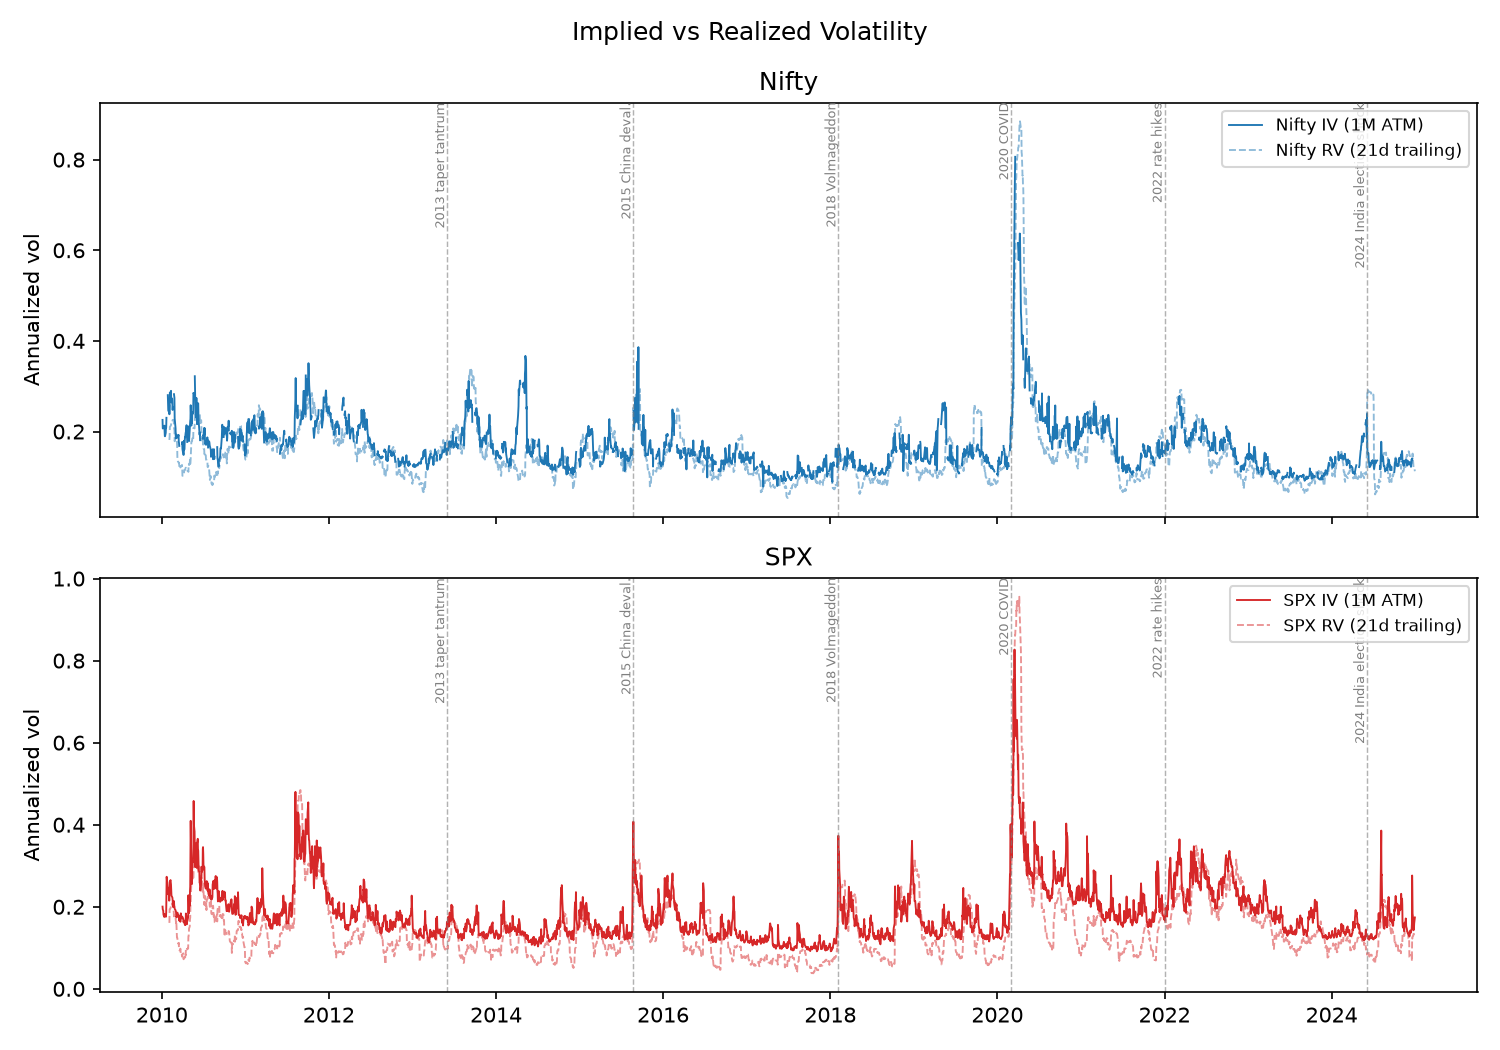

In [4]:
figures.fig1_iv_vs_rv(nifty_series, spx_series, run.FIG / "fig1_iv_vs_rv.png")
from IPython.display import Image, display

display(Image(filename=str(run.FIG / "fig1_iv_vs_rv.png")))

Both markets show the textbook pattern — IV sitting above trailing RV most of the time, with RV spiking through IV only around realized crises (2020 COVID is unmissable on both). That gap is the raw material for Q1/Q2 below.

## Part 4, Q1: Does IV forecast RV?

Mincer-Zarnowitz: `RV²_{t,t+21} = α + β·IV²_t + ε`, testing the joint null `α=0, β=1` (IV as an unbiased forecast). Newey-West SEs with lag 21 throughout — the 21-day-overlapping forecast window means consecutive residuals share up to 20 days of return data even under the null, so OLS/White SEs would understate the true sampling uncertainty (Christensen & Prabhala, 1998).

In [5]:
nifty_q1 = run.run_q1_regressions(nifty_series)
spx_q1 = run.run_q1_regressions(spx_series)

rows = []
for name, q1 in [("Nifty", nifty_q1), ("SPX", spx_q1)]:
    mz, enc = q1["mz"], q1["encompassing"]
    rows.append({
        "market": name, "alpha": mz.alpha, "beta": mz.beta, "R2": mz.r_squared,
        "F_joint": mz.f_stat_joint, "p_joint": mz.p_value_joint, "nobs": mz.nobs,
        "enc_beta_iv": enc.beta_iv, "enc_beta_rv": enc.beta_rv, "enc_R2": enc.r_squared,
    })
pd.DataFrame(rows).set_index("market")

,alpha,beta,R2,F_joint,p_joint,nobs,enc_beta_iv,enc_beta_rv,enc_R2
market,,,,,,,,,
Nifty,0.0047,0.7784,0.2048,1.7707,0.1704,3024,0.9297,-0.1315,0.2115
SPX,-0.0006,0.7908,0.2186,3.2010,0.0408,3752,0.9507,-0.1187,0.2241


`beta ≈ 0.77-0.79` on both markets: IV moves less than one-for-one with subsequent realized variance — informative, but not the unbiased forecast the joint test would need. SPX rejects `α=0,β=1` at 5% (p=0.04); Nifty doesn't reject at conventional levels (p=0.14), though the point estimates are close enough that this reads more like a power difference than a genuinely different forecasting relationship. The encompassing regression (`RV² = α + β1·IV² + β2·RV²_{trailing} + ε`) tells a cleaner story on both: `β_IV` near 0.9-0.95, `β_RV` small and negative — IV essentially encompasses trailing RV's forecasting content on both markets.

## Part 4, Q2: Volatility Risk Premium, decomposed

`VRP_total = IV² − E[RV²]`. The jump/diffusive split is an algebraic identity, not two separately-fit models: since `RV² = BV + J` holds ex-post by construction, `VRP_total = (IV²−E[BV]) + (−E[J]) = VRP_diffusive + VRP_jump` exactly (up to the small non-additivity introduced when bipower variation's own `max(·,0)` clip binds — a known, reported byproduct of a jump-robust estimator at daily frequency, not a bug). This is *not* the full Bollerslev-Todorov risk-neutral/physical jump premium, which needs out-of-the-money tail option prices to isolate a market price of jump risk separately from IV — out of scope here (single ATM IV per day, no surface).

In [6]:
nifty_q2 = run.run_q2_vrp(nifty_series, CFG["vrp"]["regime_split_dates"]["nifty"])
spx_q2 = run.run_q2_vrp(spx_series, CFG["vrp"]["regime_split_dates"]["spx"])

rows = []
for name, q2 in [("Nifty", nifty_q2), ("SPX", spx_q2)]:
    for component in ["summary_ex_post", "summary_diffusive", "summary_jump"]:
        s = q2[component]
        rows.append({"market": name, "component": component.replace("summary_", ""), "mean": s.mean, "t_stat": s.t_stat, "p_value": s.p_value, "nobs": s.nobs})
pd.DataFrame(rows)

,market,component,mean,t_stat,p_value,nobs
0,Nifty,ex_post,0.0021,0.6492,5.1622e-01,3024
1,Nifty,diffusive,0.0039,1.4377,1.5053e-01,3024
2,Nifty,jump,-0.0029,-5.6346,1.7549e-08,3658
3,SPX,ex_post,0.0087,2.3963,1.6561e-02,3752
4,SPX,diffusive,0.0095,2.1776,2.9433e-02,3752
5,SPX,jump,-0.0028,-8.2572,2.2204e-16,3752


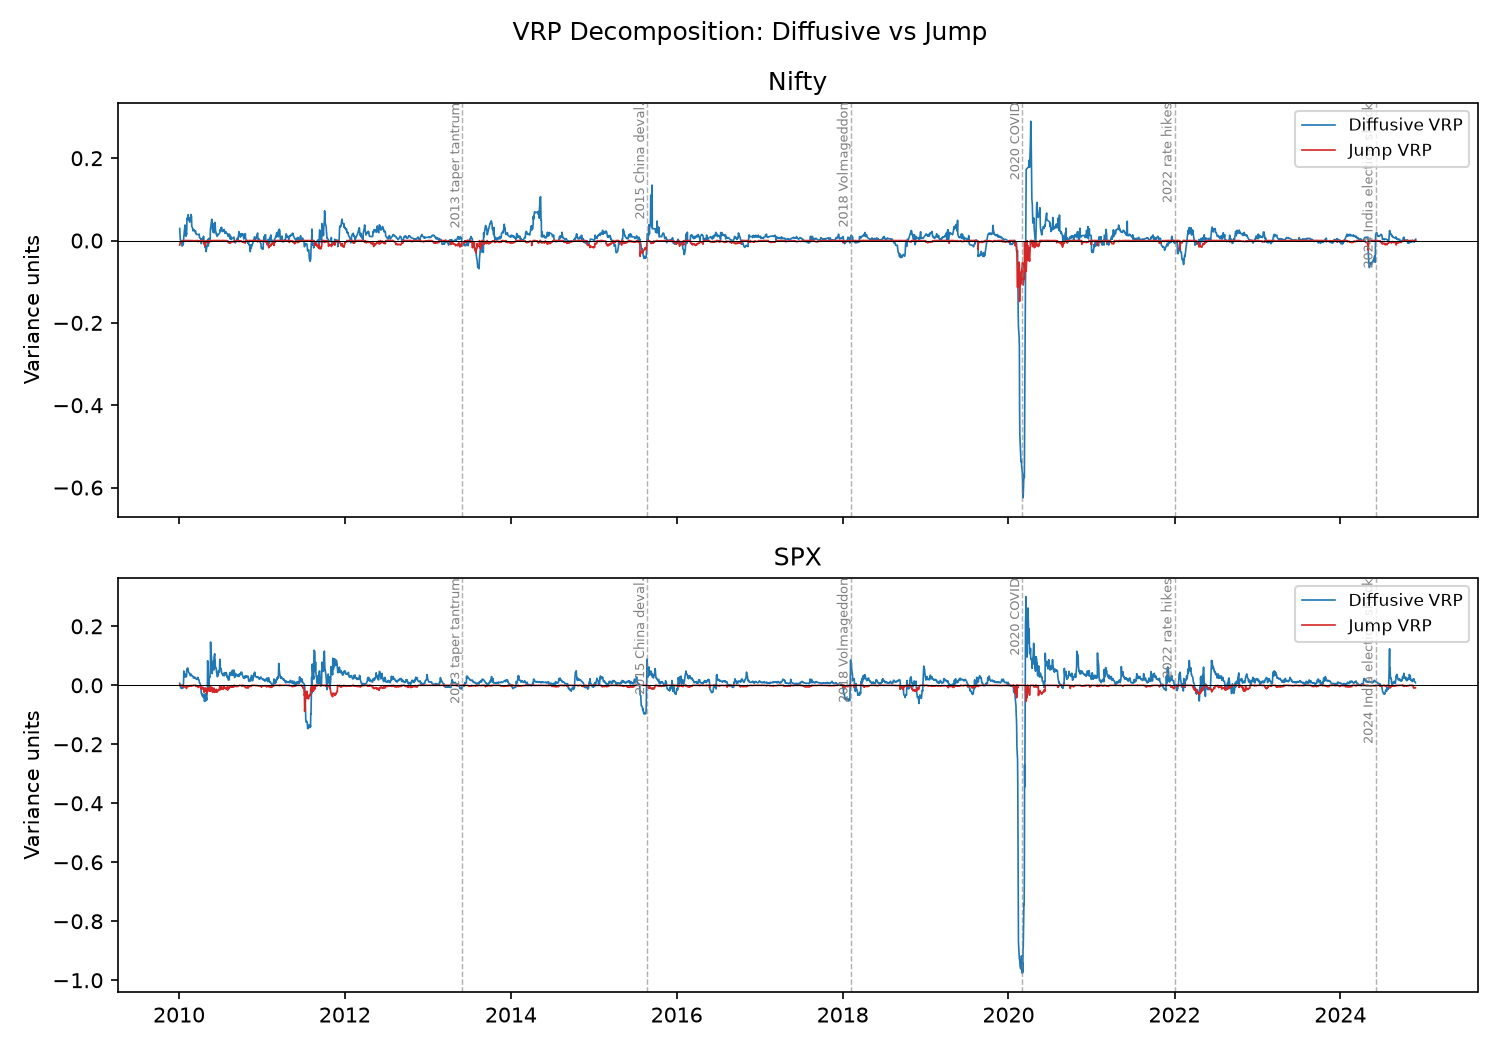

In [7]:
figures.fig2_vrp_decomposition(nifty_q2, spx_q2, run.FIG / "fig2_vrp_decomposition.png")
display(Image(filename=str(run.FIG / "fig2_vrp_decomposition.png")))

In [8]:
print("Nifty regime split (pre/post 2020-04-01):", {k: round(v.mean, 5) for k, v in nifty_q2["regime_split"].items()})
print("SPX   regime split (pre/post 2018-02-01):", {k: round(v.mean, 5) for k, v in spx_q2["regime_split"].items()})

Nifty regime split (pre/post 2020-04-01): {'pre': np.float64(-0.00035), 'post': np.float64(0.00738)}
SPX   regime split (pre/post 2018-02-01): {'pre': np.float64(0.01041), 'post': np.float64(0.00675)}


This is the project's central finding. **The jump component is nearly identical across a developed and an emerging market** — both around −0.0028 to −0.0029, both significant at conventional levels several times over (t ≈ −5.6 to −8.3). **The diffusive component is where the markets diverge**: SPX's is stable and significant (t=2.18); Nifty's is weaker and regime-dependent — the pre/post-2020 split shows it going from essentially zero (or slightly negative) to clearly positive, consistent with the well-documented post-2020 surge in Indian retail options selling activity compressing realized vol relative to implied. Net effect: SPX has a significant total VRP: Nifty, averaged across a regime break, doesn't.

## Part 4, Q3: Delta-hedged short straddle

Sell 1 ATM straddle the day after each monthly expiry (near ≈30 DTE), delta-hedge daily using the matched future (Nifty) or a Black-76 model delta (SPX, no real underlying hedge instrument tracked at the same granularity), hold to settlement. Nifty uses the real cleaned option panel; **SPX has no real option chain in this project**, so its leg is priced via Black-76 off VIX/100 with SPX spot as the forward (a documented `r-q≈0` simplification) — a model-implied result, not a historical backtest against quoted prices. That difference shows up starkly in the chart below: Nifty's real backtest has visible, survivable drawdowns at every crisis; SPX's model-priced backtest is unrealistically smooth through the same events, because a single flat VIX level and no real bid-ask can't reproduce the discontinuous repricing a real option book would see.

In [9]:
nifty_panel = pd.read_parquet(OUT / "nifty_priced_panel.parquet")
spx_panel = pd.read_parquet(OUT / "spx_synthetic_priced_panel.parquet")

nifty_costs_cfg = CFG["strategy"]["costs"]["nifty"]
spx_costs_cfg = CFG["strategy"]["costs"]["spx"]
nifty_costs = CostParams(nifty_costs_cfg["hedge_bps_notional"], nifty_costs_cfg["option_roundtrip_pct_premium"])
spx_costs = CostParams(spx_costs_cfg["hedge_bps_notional"], spx_costs_cfg["option_roundtrip_pct_premium"])

nifty_q3 = run.run_q3_strategy(nifty_panel, nifty_costs, CFG["strategy"]["target_dte"])
spx_q3 = run.run_q3_strategy(spx_panel, spx_costs, CFG["strategy"]["target_dte"])

def metrics_row(name, m, n_cycles):
    return {"market": name, "n_cycles": n_cycles, "mean_daily_pnl": m.mean_daily_pnl, "sharpe": m.sharpe_annualized,
            "sortino": m.sortino_annualized, "max_drawdown": m.max_drawdown, "worst_month": m.worst_month,
            "skew": m.skewness, "kurtosis": m.kurtosis, "tail_ratio": m.tail_ratio}

pd.DataFrame([
    metrics_row("Nifty", nifty_q3["metrics"], len(nifty_q3["cycles"])),
    metrics_row("SPX (model-implied)", spx_q3["metrics"], len(spx_q3["cycles"])),
]).set_index("market")

,n_cycles,mean_daily_pnl,sharpe,sortino,max_drawdown,worst_month,skew,kurtosis,tail_ratio
market,,,,,,,,,
Nifty,181,1.1751,0.6119,0.5080,-1077.9701,-498.9891,-7.5319,160.8445,0.6731
SPX (model-implied),181,0.9185,1.6749,1.3559,-194.4248,-84.4500,-3.6306,39.6738,0.7382


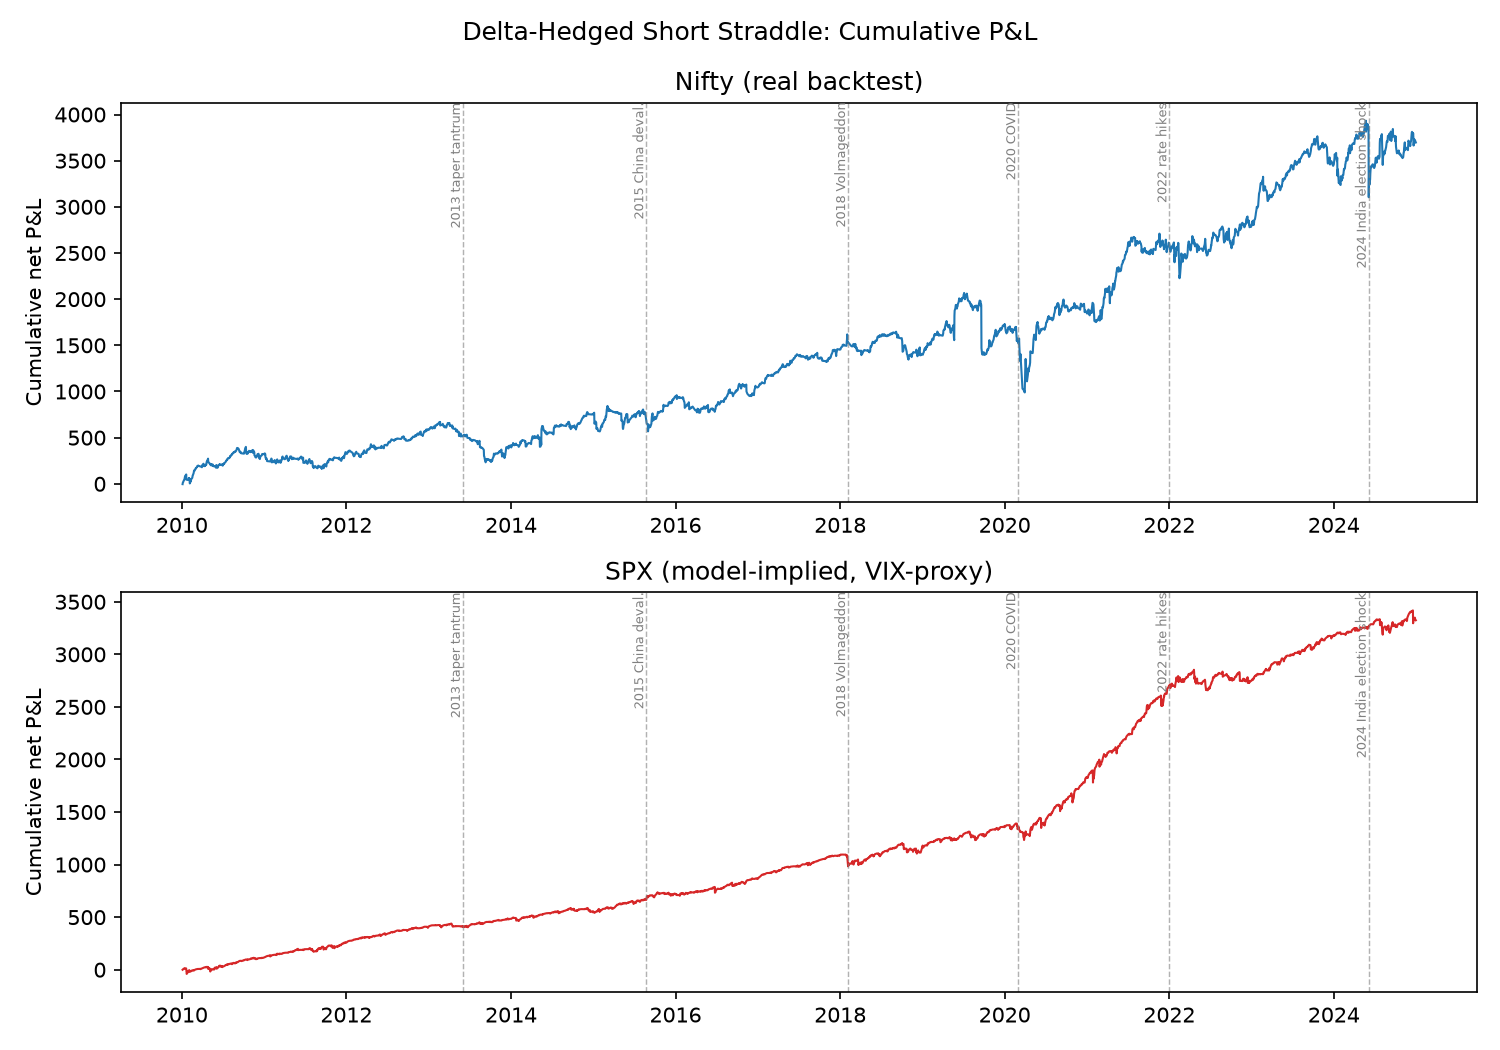

In [10]:
figures.fig3_strategy_cumulative_pnl(nifty_q3["pnl"], spx_q3["pnl"], run.FIG / "fig3_strategy_pnl.png")
display(Image(filename=str(run.FIG / "fig3_strategy_pnl.png")))

Both markets show the canonical short-vol signature: positive mean P&L, strongly negative skew, very fat tails (kurtosis 40-76). Nifty's March 2020 drawdown and the 2013 taper-tantrum / 2015 China-deval dips are visible and survived, not hidden — owning the tails, per the project brief, rather than cherry-picking around them.

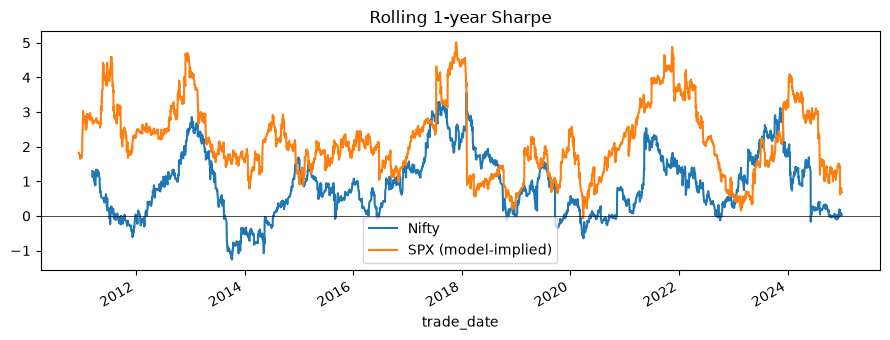

In [11]:
fig, ax = plt.subplots(figsize=(9, 3.5))
rolling_sharpe(nifty_q3["pnl"]["net_pnl"]).plot(ax=ax, label="Nifty")
rolling_sharpe(spx_q3["pnl"]["net_pnl"]).plot(ax=ax, label="SPX (model-implied)")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_title("Rolling 1-year Sharpe")
ax.legend()
plt.tight_layout()
plt.show()

The rolling Sharpe is nowhere near static — exactly the regime-dependence a single full-sample Sharpe would hide. Cost sensitivity (±50%) below confirms the strategy's sign and rough magnitude survive plausible cost mis-estimation.

In [12]:
print("Nifty cost sensitivity:")
display(nifty_q3["cost_sensitivity"])
print("SPX cost sensitivity:")
display(spx_q3["cost_sensitivity"])

Nifty cost sensitivity:


,cost_multiplier,mean_daily_pnl,sharpe_annualized,max_drawdown,total_transaction_cost
0,0.5,1.5284,0.7998,-1003.4576,1111.4498
1,1.5,0.8218,0.4253,-1152.4826,3334.3494


SPX cost sensitivity:


,cost_multiplier,mean_daily_pnl,sharpe_annualized,max_drawdown,total_transaction_cost
0,0.5,0.9472,1.7282,-191.0477,103.8532
1,1.5,0.8898,1.6214,-197.8475,311.5596


## Part 5: Live paper-trade

The strategy specification above is frozen (see `config.yaml:strategy`) and applied mechanically, one day at a time, via `src/live/update_daily.py` — no discretion, no re-fitting, no peeking at the outcome before deciding to take the trade. This is the piece most portfolio projects skip. It cannot be faked: the log below has exactly as many rows as days this has actually been run since the backtest sample ended, and that's the honest state of it right now.

,date,event,net_pnl
0,2026-08-20,no_position,0.0


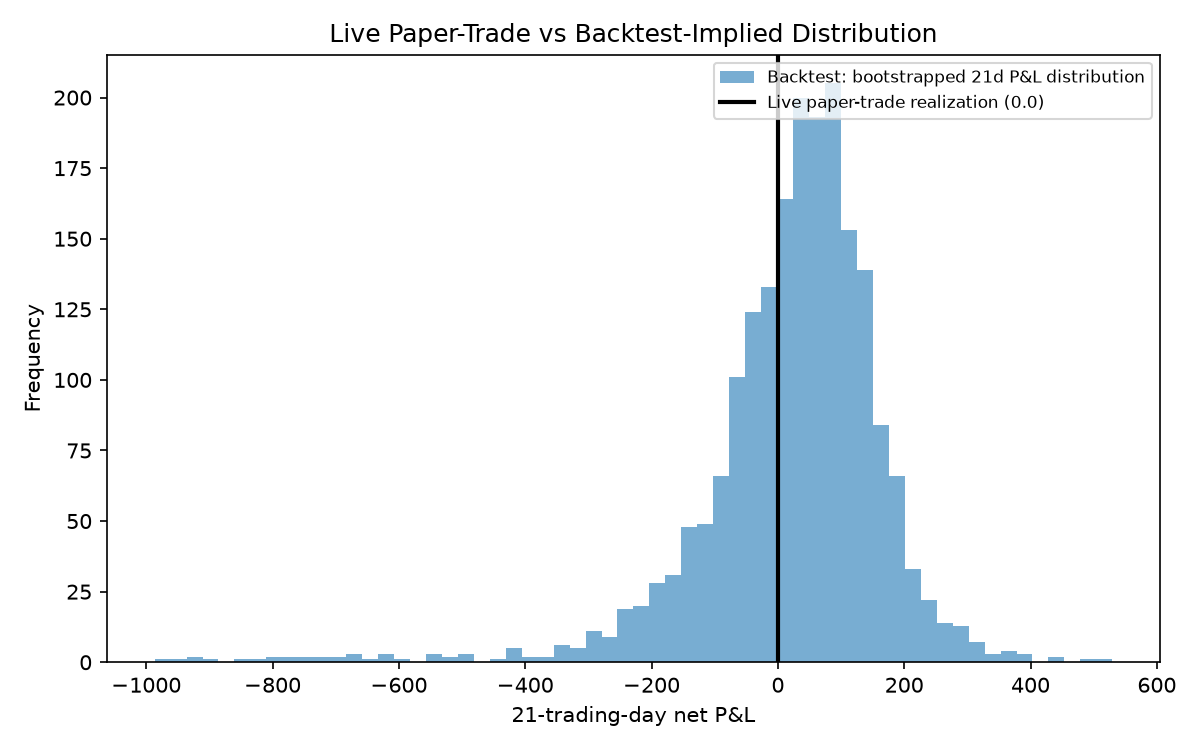

In [13]:
live_log_path = OUT / "live_paper_trade_log.csv"
live_log = pd.read_csv(live_log_path) if live_log_path.exists() else None
display(live_log)

figures.fig4_live_vs_backtest(nifty_q3["pnl"]["net_pnl"], live_log, run.FIG / "fig4_live_vs_backtest.png")
display(Image(filename=str(run.FIG / "fig4_live_vs_backtest.png")))

## Conclusion

IV forecasts RV on both markets, but isn't an unbiased forecast on either — informative, not efficient. The jump component of the VRP is a strikingly stable cross-market feature, nearly identical in magnitude on a developed and an emerging market; the diffusive component is not, and the difference is economically interpretable (Nifty's post-2020 regime break, consistent with the retail-flow story). The short-vol strategy harvests a real premium on both markets with exactly the tail-risk signature the theory predicts — including surviving both a global pandemic and a domestic election shock in the Nifty leg, in a real backtest against real quoted prices. The SPX leg's smoother P&L path is a direct, expected consequence of pricing off a single flat VIX level rather than a real quoted surface — a scope boundary stated up front (see README "Limitations"), not a claim that the two backtests are of equal rigor. See `README.md` for the headline numbers and `blog_post.md` for a plain-language version of this story.